# Lab 05: Xây dựng mô hình  K-Nearest Neighbors (k-NN))

## Mục tiêu
- Hiểu cơ chế hoạt động của thuật toán KNN.
- Cài đặt mô hình KNN **từ đầu bằng Python**, không dùng thư viện học máy.
- Thực hiện dự đoán và đánh giá hiệu quả mô hình.
- So sánh với mô hình `KNeighborsClassifier` của sklearn.
- Trực quan hóa ranh giới phân loại khi dữ liệu 2 chiều.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

## Xây dựng class KNNClassifier

In [2]:
class KNNClassifier:
    # Khởi tạo mô hình với tham số k: số láng giềng gần nhất
    def __init__(self, k=3):
        self.k = k
        
    # Phương thức huấn luyện: k-NN không tạo mô hình -> chỉ lưu trữ dữ liệu huấn luyện
    def fit(self, X, y):
        self.X_train = X
        
        self.y_train = y
    
    # Tính khoảng cách Euclidean giữa hai điểm
    def _euclidean_distance(self, x1, x2):
        sum = np.sum((x1 - x2)**2)
        return np.sqrt(sum)
    # Dự đoán nhãn cho một điểm dữ liệu
    def _predict(self, x):
        # Tính khoảng cách từ điểm x đến tất cả các điểm trong tập huấn luyện
        distances = []
        for xi in self.X_train:
            d = self._euclidean_distance(x, xi)
            distances.append(d)
        # Lấy index của k láng giềng gần nhất
        k_indices = np.argsort(distances)[:self.k]
        # Lấy nhãn của k láng giềng gần nhất
        k_labels = []
        for idx in k_indices:
            label = self.y_train[idx]
            k_labels.append(label)
        # Trả về nhãn phổ biến nhất trong số k láng giềng
        most = np.bincount(k_labels).argmax()
        return most  
    # Dự đoán nhãn cho tập dữ liệu
    def predict(self, X):
        predictions = []
        for xi in X:
            predictions.append(self._predict(xi))
        return np.array(predictions)


## Kiểm tra mô hình với Tập dữ liệu Iris

- Sử dụng phương thức `load_iris` trong module `sklearn.datasets`để tải **_Tập dữ liệu Iris_**. (Chọn lọc lớp 1 và 2, loại bỏ lớp 0 để làm ví dụ phân loại nhị phân)
- Sử dụng `train_test_split` trong module `sklearn.model_selection` để chia tập dữ liệu thành tập huấn luyện và tập kiểm tra theo tỷ lệ 80:20.
- Huấn luyện mô hình K-NN vừa xây dựng với tập huấn luyện.
- Dự đoán nhãn của tập kiểm tra.
- Trực quan hóa ma trận nhầm lẫn và tính độ chính xác của mô hình qua các chỉ số: *Accuracy*, *Precision*, *Recall*, *F1-score*.

In [3]:
# Tải Tập dữ liệu Iris
iris = load_iris()
# Chọn lọc lớp 0 và 1 để làm ví dụ phân loại nhị phân
data = iris.data[iris.target != 0]
target = iris.target[iris.target != 0]
# Chuẩn hóa dữ liệu
data = StandardScaler().fit_transform(data)


In [4]:
# Split dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

In [5]:
# Huấn luyện mô hình k-NN
model = KNNClassifier(k=3)
model.fit(X_train, y_train)

In [6]:
# Dự đoán trên tập kiểm tra
predictions = model.predict(X_test)

F1 Score: 0.8695652173913043
Precision: 0.9090909090909091
Recall: 0.8333333333333334
Accuracy: 0.85


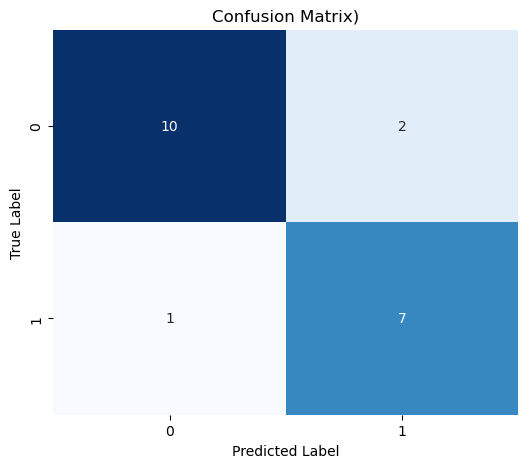

In [36]:
import seaborn as sns
# Trực quan hóa ma trận nhầm lẫn và tính các chỉ số đánh giá
cm = confusion_matrix(y_test, predictions)
# print("Confusion Matrix:\n", cm)
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions) 
f1 = f1_score(y_test, predictions)
print("F1 Score:", f1) 
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accuracy)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title(f'Confusion Matrix)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()



## So sánh với KNeighborsClassifier của sklearn

Thực hiện các bước tương tự như trên nhưng sử dụng `KNeighborsClassifier` từ `sklearn.neighbors`. So sánh kết quả với mô hình KNN tự xây dựng.

F1 Score (sklearn): 0.8695652173913043
Precision: 0.9090909090909091
Recall: 0.8333333333333334
Accuracy: 0.85


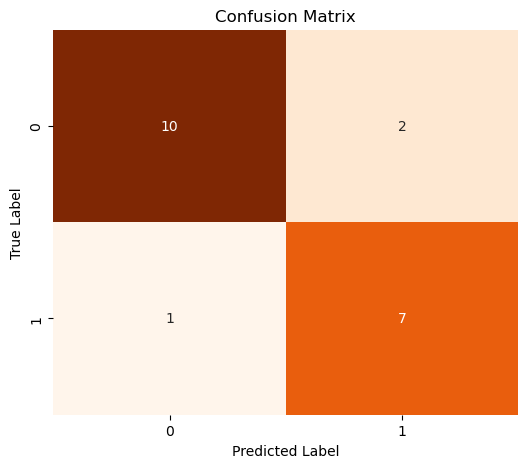

In [37]:
# Sử dụng KNeighborsClassifier từ scikit-learn để so sánh
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
pres = knn.predict(X_test)
cm_sklearn = confusion_matrix(y_test, pres)
accuracy_sklearn = accuracy_score(y_test, pres)
presision_sklearn = precision_score(y_test, pres)
f1_sklearn = f1_score(y_test, pres)
recall_sklearn = recall_score(y_test, pres)
print("F1 Score (sklearn):", f1_sklearn)
print("Precision:", presision_sklearn)
print("Recall:", recall_sklearn)
print("Accuracy:", accuracy_sklearn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Oranges', cbar=False)

plt.title(f'Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

=> kết quả giống với dùng kkn của thư viện sklearn


## Đánh giá ảnh hưởng của tham số k

- Giảm dữ liệu xuống 2 chiều (chỉ sử dụng 2 đặc trưng đầu tiên của tập dữ liệu Iris) để dễ dàng trực quan hóa ranh giới phân loại.
- Sử dụng `train_test_split` để chia tập dữ liệu thành tập huấn luyện và tập kiểm tra.
- Thiết lập các giá trị khác nhau cho tham số k (ví dụ: 1, 3, 5, 9, 15, 17, 19).
- Huấn luyện và đánh giá mô hình KNN với từng giá trị k.
- Trực quan hóa ranh giới phân loại trên biểu đồ 2D cho từng giá trị k.
- So sánh hiệu suất của mô hình qua các giá trị k khác nhau và rút ra kết luận về ảnh hưởng của tham số k đến hiệu quả phân loại.

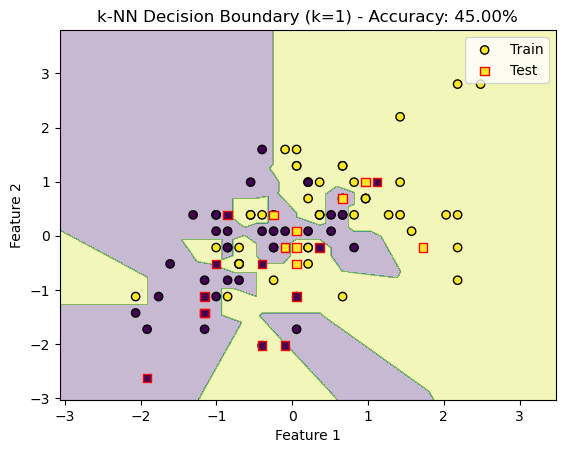

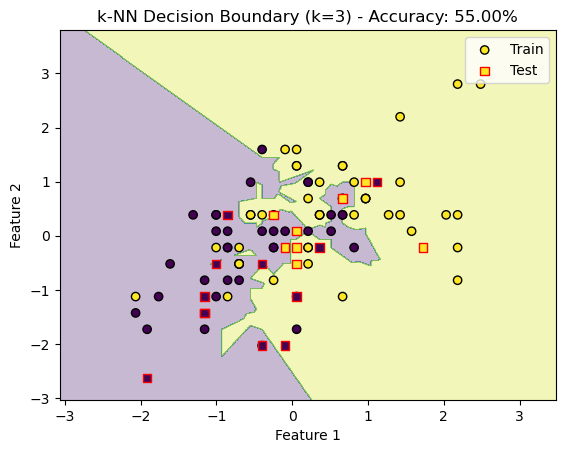

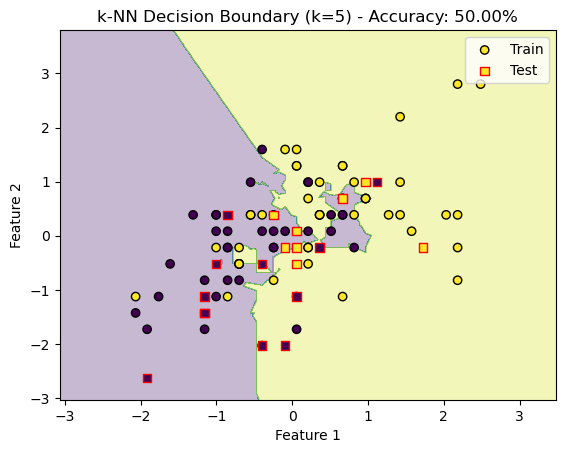

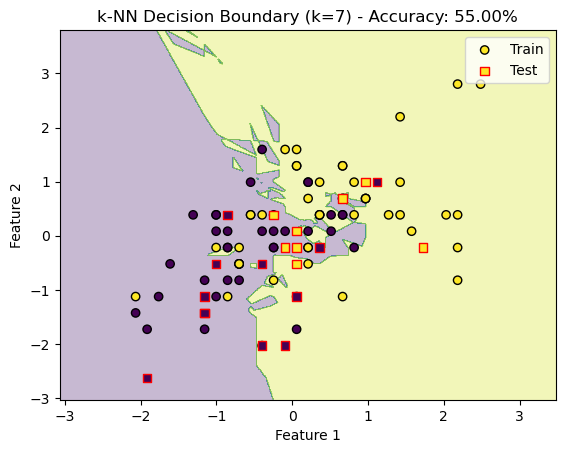

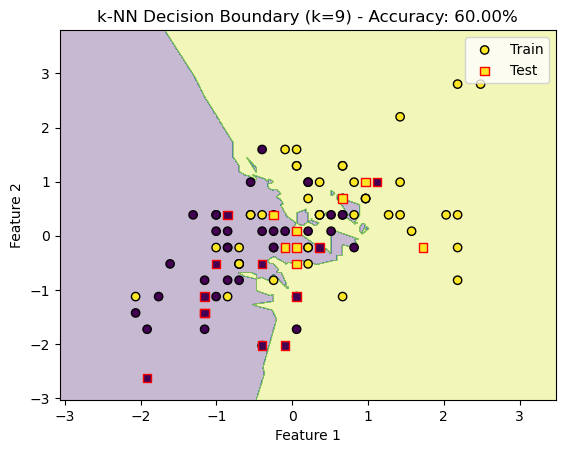

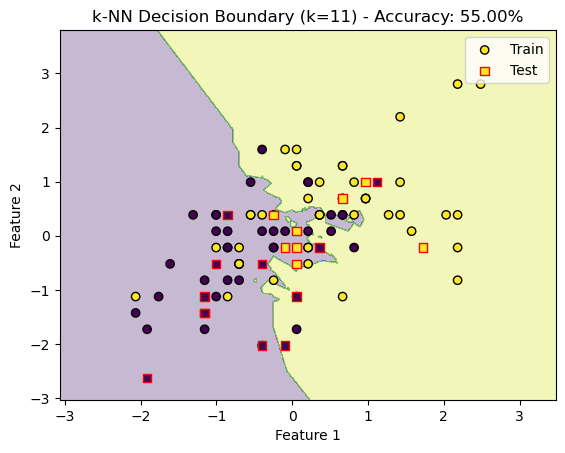

In [17]:
# Giảm dữ liệu xuống 2 chiều (chỉ sử dụng 2 đặc trưng đầu tiên của tập dữ liệu Iris) để dễ dàng trực quan hóa ranh giới phân loại.
data_2d = data[:,:2]

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(data_2d, target, test_size=0.2, random_state=42)
# Thiết lập các k khác nhau và so sánh hiệu suất
k_values = [1, 3, 5, 7, 9, 11]
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_2d, y_train_2d)
    y_pred = knn.predict(X_test_2d)
    acc = accuracy_score(y_test_2d, y_pred)
    accuracies.append(acc)
    # Trực quan hóa ranh giới phân loại
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_2d, edgecolors='k', marker='o', label='Train')
    plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_2d, edgecolors='r', marker='s',  label='Test')
    plt.title(f'k-NN Decision Boundary (k={k}) - Accuracy: {acc * 100:.2f}%')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()   
    plt.show()  

**Nhận xét ảnh hưởng của tham số k đến hiệu quả phân loại.**

- k quá nhỏ làm kết quả dự đoán bị nhiễu (overfit)
- k quá lớn dẫn đến kết quả đầu ra bị mất đi đặc trưng của dữ liệu đối với những mẫu gần nhất (underfit)